# Behavioral Shift Detection & Pattern Transition Analysis

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")


## 2. Load Dataset

In [2]:

df = pd.read_csv("sales_06_FY2020-21.csv")
df.head()


,order_id,order_date,status,item_id,sku,qty_ordered,price,value,discount_amount,total,...,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name,Discount_Percent
0,100354678,2020-10-01,received,574772.0,oasis_Oasis-064-36,21.0,89.9,1798.0,0.0,1798.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
1,100354678,2020-10-01,received,574774.0,Fantastic_FT-48,11.0,19.0,190.0,0.0,190.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
2,100354680,2020-10-01,complete,574777.0,mdeal_DMC-610-8,9.0,149.9,1199.2,0.0,1199.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
3,100354680,2020-10-01,complete,574779.0,oasis_Oasis-061-36,9.0,79.9,639.2,0.0,639.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
4,100367357,2020-11-13,received,595185.0,MEFNAR59C38B6CA08CD,2.0,99.9,99.9,0.0,99.9,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0


## 3. Data Overview

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          286392 non-null  object 
 1   order_date        286392 non-null  object 
 2   status            286392 non-null  object 
 3   item_id           286392 non-null  float64
 4   sku               286392 non-null  object 
 5   qty_ordered       286392 non-null  float64
 6   price             286392 non-null  float64
 7   value             286392 non-null  float64
 8   discount_amount   286392 non-null  float64
 9   total             286392 non-null  float64
 10  category          286392 non-null  object 
 11  payment_method    286392 non-null  object 
 12  bi_st             286392 non-null  object 
 13  cust_id           286392 non-null  float64
 14  year              286392 non-null  int64  
 15  month             286392 non-null  object 
 16  ref_num           28

## 4. Data Cleaning

In [4]:

df_clean = df.drop_duplicates()
df_clean.isnull().sum()


order_id            0
order_date          0
status              0
item_id             0
sku                 0
qty_ordered         0
price               0
value               0
discount_amount     0
total               0
category            0
payment_method      0
bi_st               0
cust_id             0
year                0
month               0
ref_num             0
Name Prefix         0
First Name          0
Middle Initial      0
Last Name           0
Gender              0
age                 0
full_name           0
E Mail              0
Customer Since      0
SSN                 0
Phone No.           0
Place Name          0
County              0
City                0
State               0
Zip                 0
Region              0
User Name           0
Discount_Percent    0
dtype: int64

## 5. Date Processing

In [5]:

df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

df_clean['Order_Year'] = df_clean['order_date'].dt.year
df_clean['Order_Month'] = df_clean['order_date'].dt.month
df_clean['Order_Weekday'] = df_clean['order_date'].dt.day_name()

df_clean[['order_date','Order_Year','Order_Month']].head()


,order_date,Order_Year,Order_Month
0,2020-10-01,2020,10
1,2020-10-01,2020,10
2,2020-10-01,2020,10
3,2020-10-01,2020,10
4,2020-11-13,2020,11


## 6. Feature Engineering (Behavioral Metrics)

In [6]:

df_clean['Avg_Order_Value'] = df_clean['total'] / df_clean['qty_ordered']
df_clean['Discount_Sensitivity'] = df_clean['discount_amount'] / (df_clean['value'] + 1)

df_clean[['Avg_Order_Value','Discount_Sensitivity']].head()


,Avg_Order_Value,Discount_Sensitivity
0,85.619048,0.0
1,17.272727,0.0
2,133.244444,0.0
3,71.022222,0.0
4,49.950000,0.0


## 7. Exploratory Data Analysis (EDA)

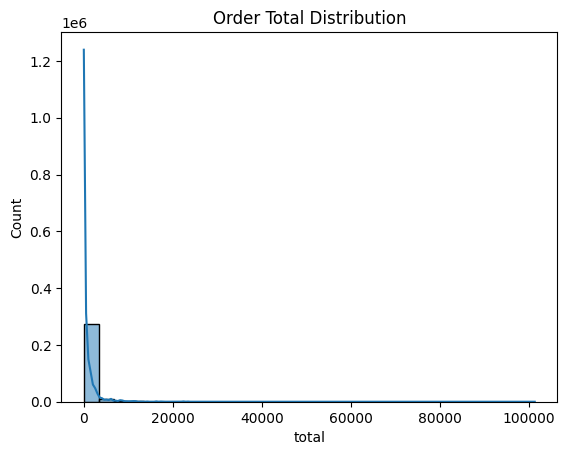

In [7]:

sns.histplot(df_clean['total'], bins=30, kde=True)
plt.title("Order Total Distribution")
plt.show()


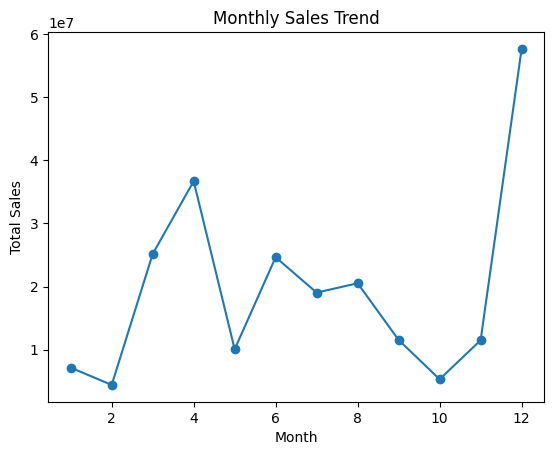

In [8]:

monthly_sales = df_clean.groupby('Order_Month')['total'].sum()

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


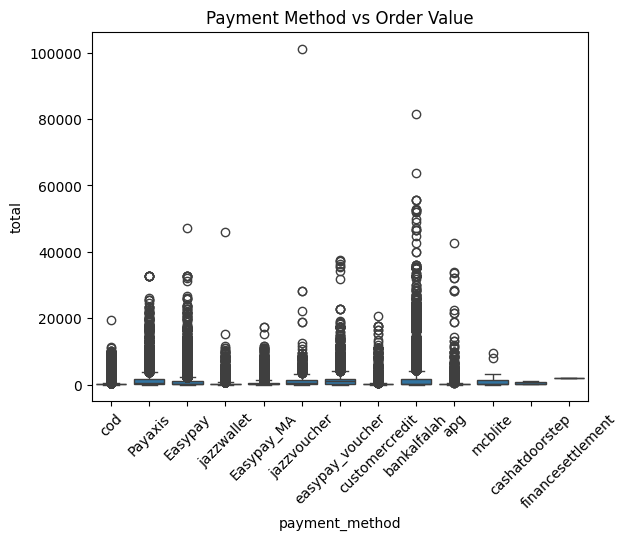

In [9]:

sns.boxplot(x='payment_method', y='total', data=df_clean)
plt.xticks(rotation=45)
plt.title("Payment Method vs Order Value")
plt.show()


## 8. Behavioral Clustering (KMeans)

In [10]:

features = [
    'qty_ordered',
    'price',
    'total',
    'Discount_Percent',
    'age',
    'Avg_Order_Value',
    'Discount_Sensitivity'
]

X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['Behavior_Cluster'] = kmeans.fit_predict(X_scaled)

df_clean[['Behavior_Cluster']].value_counts()


Behavior_Cluster
3                   104104
1                   102160
0                    71895
2                     8233
Name: count, dtype: int64

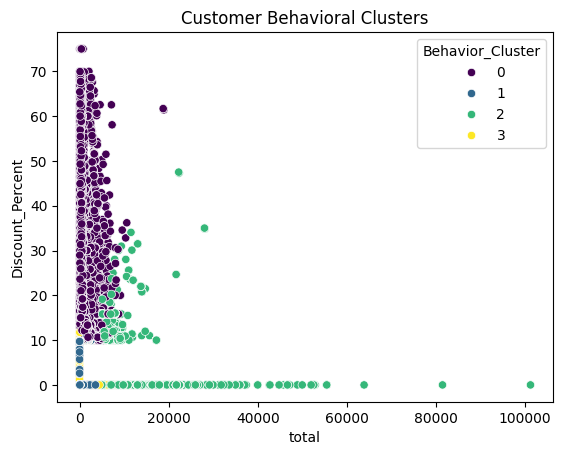

In [11]:

sns.scatterplot(
    x='total',
    y='Discount_Percent',
    hue='Behavior_Cluster',
    data=df_clean,
    palette='viridis'
)
plt.title("Customer Behavioral Clusters")
plt.show()


## 9. Pattern Transition Analysis (PCA)

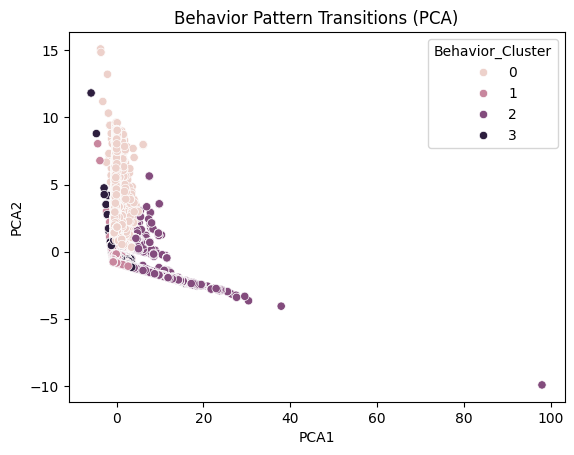

In [12]:

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_clean['PCA1'] = pca_components[:,0]
df_clean['PCA2'] = pca_components[:,1]

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Behavior_Cluster',
    data=df_clean
)
plt.title("Behavior Pattern Transitions (PCA)")
plt.show()


## 10. Machine Learning – Cluster Prediction

In [13]:

X_ml = df_clean[features]
y_ml = df_clean['Behavior_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14359
           1       1.00      1.00      1.00     20443
           2       1.00      1.00      1.00      1630
           3       1.00      1.00      1.00     20847

    accuracy                           1.00     57279
   macro avg       1.00      1.00      1.00     57279
weighted avg       1.00      1.00      1.00     57279

